In [ ]:
import os
import re
import ast
import json
import anthropic
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from dotenv import load_dotenv
from pydantic import BaseModel, Field

In [ ]:
# Judge model: Claude, distinct from the gpt-5-2 systems being evaluated (see paper_tasks/*.json).
# Using a different model family for judging avoids favoring outputs stylistically similar to the judge.
KEYS_FILE = "../api_key.env"
load_dotenv(KEYS_FILE)
client = anthropic.Anthropic(api_key=os.getenv("ANTHROPIC_API_KEY"))
MODEL     = "claude-opus-4-7"

In [ ]:
# All 12 task folders (used to build the question lookup)
ALL_TASK_FOLDERS = [
    "T1__crystal_gap",
    "T2__solar_cell",
    "T3__topological_insulator",
    "T4__multi_kinase",
    "T5__tp53_isoforms",
    "T6__pi3k_pathway",
    "T7__ml_topics",
    "T8__lipinski_ro5",
    "T9__diffusion_maturity",
    "T10__kinase_admet",
    "T11__vegfr2_resistance",
    "T12__polypharmacology",
]
# The 7 systems compared, ordered from simplest baseline to the full proposed system
# (last three are Artifact Reactor ablations, weakest ablation first).
SYSTEM_ORDER = [
    "single_model_direct",
    "single_agent_with_tools",
    "non_signaling_multi_agent",
    "centralized_orchestration",
    "artifact_reactor_no_provenance",
    "artifact_reactor_no_parallel",
    "artifact_reactor",
]
RESULTS_CACHE   = Path("llm_judge_results.json")  # written in step 6, read back by downstream analysis
PAPER_TASKS_DIR = Path("paper_tasks")

## 1. Extract questions for all 12 tasks

Questions live inside `artifact_reactor` files as a `bm_anchor` JSON block.
We extract once per task and use the result as a lookup for all 7 systems.

In [ ]:
def extract_question(raw_output: str) -> str:
    """Extract question from the bm_anchor block using ast.literal_eval.
    Background is excluded — the question is self-contained and background
    is only stored in artifact_reactor files, making it unavailable for other systems."""
    m = re.search(
        r'\[research_query from bm_anchor\]\s*({.*?})\s*(?:---|$)',
        raw_output, re.DOTALL,
    )
    if m:
        try:
            return ast.literal_eval(m.group(1)).get('question', '')
        except Exception:
            pass
    return ''


def build_task_questions(task_folders: list) -> pd.DataFrame:
    """Extract questions for all tasks. Returns a DataFrame with task, task_name, question."""
    rows = []
    for folder in task_folders:
        label     = folder.split('__')[0]
        task_name = folder.split('__', 1)[1]
        task_path = PAPER_TASKS_DIR / folder

        # bm_anchor is only present in artifact_reactor output, so we always source the
        # question from that system's file, even when scoring the other 6 systems.
        candidates = sorted(task_path.glob('*artifact_reactor__*.json'))
        exact  = [f for f in candidates if 'no_' not in f.name]
        target = exact[0] if exact else (candidates[0] if candidates else None)

        question = ''
        if target:
            with open(target, encoding='utf-8') as f:
                data = json.load(f)
            question = extract_question(data.get('raw_output', ''))
        else:
            print(f"[warn] no artifact_reactor file found for {label}")

        rows.append({'task': label, 'task_name': task_name, 'question': question})

    return pd.DataFrame(rows)


df_questions = build_task_questions(ALL_TASK_FOLDERS)
print(f"Extracted questions for {len(df_questions)} tasks "
      f"({(df_questions['question'] == '').sum()} empty)")

# Lookup dict used downstream: {'T1': 'Which ABO3 ...', ...}
TASK_QUESTIONS = dict(zip(df_questions['task'], df_questions['question']))

## 2. Load result files and extract system answer

**What we send to the judge per system type:**
- `artifact_reactor` variants → only the `[analysis_result ...]` blocks (synthesis outputs).  
  The rest of the raw_output is raw tool JSON dumps (PubMed records, Materials Project dicts, etc.) — not the system's answer.
- All other systems → full `raw_output`  (it IS the answer).

In [ ]:
def extract_synthesis_answer(raw_output: str, system: str) -> str:
    """For artifact_reactor variants, return only [analysis_result from X] blocks.
    For no_provenance, return non-raw-data sections. For all others, return full output.
    """
    if "artifact_reactor" not in system:
        return raw_output

    sections = re.split(r"\n---+\n", raw_output)

    if "no_provenance" in system:
        RAW_PREFIXES = ("{", "[{", "Searching PubMed:", "Searching PubChem:")
        result_blocks = []
        for s in sections:
            s = s.strip()
            if not re.match(r"^\[\w+\]", s):
                continue
            header_end = s.index("]") + 1
            content = s[header_end:].strip()
            if content and not any(content.startswith(p) for p in RAW_PREFIXES):
                result_blocks.append(s)
    else:
        result_blocks = [
            s.strip() for s in sections
            if re.match(r"\s*\[analysis_result from \w+\]", s)
        ]

    if result_blocks:
        return "\n\n---\n\n".join(result_blocks)
    return raw_output


answers = []
missing = []
for folder in ALL_TASK_FOLDERS:
    label = folder.split("__")[0]
    task_path = PAPER_TASKS_DIR / folder
    for system in SYSTEM_ORDER:
        filename = task_path / f"{label}__{system}__gpt-5-2__seed42.json"
        if not filename.exists():
            missing.append(str(filename))
            continue

        with open(filename, encoding="utf-8") as f:
            data = json.load(f)

        raw_output = data.get("raw_output", "")
        synthesis  = extract_synthesis_answer(raw_output, system)

        # For artifact_reactor variants, pipeline_trace is the full raw_output so the
        # judge can verify tool calls for evidence_grounding. For other systems the
        # synthesis IS the full output, so no separate trace is needed.
        is_ar = "artifact_reactor" in system
        pipeline_trace = raw_output if is_ar else ""

        answers.append({
            "task": label,
            "system": system,
            "question": TASK_QUESTIONS.get(label, ""),
            "answer": synthesis,
            "pipeline_trace": pipeline_trace,
            "answer_len": len(synthesis),
            # Programmatic (regex/rule-based) quality score computed by the benchmark
            # harness at run time (see supplementary experiments/harness/evaluate.py).
            # This is NOT produced by the LLM judge — it's loaded straight from the result file.
            "product_quality_score": data.get("product_quality_score"),
        })

df_records = pd.DataFrame(answers)
print(f"Loaded {len(df_records)} of {len(ALL_TASK_FOLDERS) * len(SYSTEM_ORDER)} expected records"
      f" ({len(missing)} missing)")
for m in missing:
    print(f"  [missing] {m}")

## 3. Define the judge's output schema

`EvalResult` validates the judge's JSON response so a malformed reply fails loudly
(caught in `evaluate_row`, step 5) instead of silently corrupting the results table.

In [6]:
class EvalResult(BaseModel):
    completeness:       float = Field(ge=1, le=5)
    evidence_grounding: float = Field(ge=1, le=5)
    rationale:          dict  = {}
    error:              str   = ''

## 4. Judge prompt

Rubric mirrors the two dimensions scored in `EvalResult`: completeness (did it answer
every requested field?) and evidence_grounding (did values come from tool calls or
from the model's parametric memory?). See step 2's markdown for what each system's
SYSTEM'S FINAL ANSWER / PIPELINE TRACE inputs actually contain.

In [ ]:
JUDGE_SYSTEM_PROMPT = """You are an expert scientific evaluator assessing AI system responses to scientific research tasks.

HOW TO READ THE RESPONSE
Each evaluation contains up to two sections:

1. SYSTEM'S FINAL ANSWER — always present. This is what you score.
   - For artifact_reactor systems it contains only the synthesis blocks per agent.
     Each agent may have retried; only the LAST non-error block per agent name is the
     final result. Prior Traceback/stderr blocks are intermediate failures — ignore them.
   - For all other systems the entire text is the answer.

2. PIPELINE TRACE — present only for artifact_reactor systems. Contains full pipeline
   output: tool call results (Materials Project dicts, PubMed JSON, RDKit output, etc.).
   Use this section ONLY to verify evidence_grounding. Do NOT use it for any other dimension.

---

SCORING RUBRIC:

1. completeness (1–5)
   Count the explicitly requested output fields in the question. Score by fraction answered.

   5 = Every requested field answered with a specific, non-trivial value.
   4 = All but one field answered; or one clearly hedged/vague value.
   3 = Roughly half the fields answered with concrete values.
   2 = Only a few fields answered; majority are missing, refused, or ERROR/N/A.
   1 = Nearly nothing answered.

   RULES:
   - ERROR / N/A / refused = missing, regardless of explanation.
   - A value that is clearly physically wrong (e.g., band_gap=0.0 eV for a known insulator
     like BaTiO₃ or SrTiO₃) = half credit, not full credit.
   - A field where the tool was attempted but failed with no usable output = missing, but
     score one notch above a field never attempted at all.

2. evidence_grounding (1–5)
   Measures whether final answer values derive from actual tool calls or parametric memory.
   Use the PIPELINE TRACE (if present) to verify which tools were called and what they returned.

   5 = All key values traceable to specific tool outputs (RDKit, PubMed PMIDs, DB records,
       python-exec stdout) that match the claims they support.
   4 = Most values from tools; one item from memory or one minor citation mismatch.
   3 = Mixed: some values clearly from tools, others from memory. OR: tool was correctly
       called but the database returned bad data (e.g., wrong polymorph with band_gap=0.0)
       — tool effort is credited even when the external source was faulty, as long as the
       ID/query was not fabricated.
   2 = Mostly parametric memory; some tool framing but citations are generic or mismatched.
   1 = Entirely parametric memory with no tool calls, or all citations are fabricated.

   RULES:
   - Parametric memory alone, no matter how accurate, cannot exceed score 2.
   - A PMID cited for a claim it does not support = ungrounded for that specific item.
   - For artifact_reactor: use the PIPELINE TRACE to verify which tools were actually
     called and what they returned.

---

Return ONLY valid JSON — no prose before or after:
{
  "completeness": <float 1-5>,
  "evidence_grounding": <float 1-5>,
  "rationale": {
    "completeness": "<one sentence naming what was answered vs missed>",
    "evidence_grounding": "<one sentence on whether final values came from tools or memory>"
  }
}
"""

JUDGE_USER_PROMPT = """Question: {question}

=== SYSTEM'S FINAL ANSWER ===
{model_answer}

=== PIPELINE TRACE (tool calls + raw data — use only for evidence_grounding) ===
{pipeline_trace}"""

In [ ]:
def evaluate_row(row):
    """Send one (question, answer, pipeline_trace) record to the judge model and
    parse its response into an EvalResult. Never raises: on any failure (bad JSON,
    schema mismatch, API error) it returns None scores plus the error string, so a
    single bad row doesn't abort the full run over all 84 records."""
    judge_user = JUDGE_USER_PROMPT.format(
        question       = str(row["question"]),
        model_answer   = str(row.get("answer") or "EMPTY").strip(),
        pipeline_trace = str(row.get("pipeline_trace") or "").strip(),
    )
    try:
        response = client.messages.create(
            model      = MODEL,
            max_tokens = 2000,
            system     = JUDGE_SYSTEM_PROMPT,
            messages   = [{"role": "user", "content": judge_user}],
        )
        if not response.content or not response.content[0].text.strip():
            raise ValueError("Empty response from API")

        raw  = response.content[0].text
        data = json.loads(raw)

        # Tolerate the judge nesting scores under a "scores" key instead of top-level.
        if "scores" in data and isinstance(data["scores"], dict):
            scores = data.pop("scores")
            data.update(scores)

        result = EvalResult(**data)
        return {
            "completeness":       result.completeness,
            "evidence_grounding": result.evidence_grounding,
            "rationale":          result.rationale,
            "error":              result.error,
        }

    except Exception as e:
        print(f"[evaluate_row ERROR] task={row.get('task','?')} system={row.get('system','?')} {e}")
        return {
            "completeness":       None,
            "evidence_grounding": None,
            "rationale":          {},
            "error":              str(e),
        }

## 5. Run judge

Sequential (unbatched) API calls, one per record — 84 calls total, ~6 minutes end to end.
`evaluate_row` catches its own errors, so a failed call leaves `None` scores for that
row rather than stopping the loop.

## 6. Persist judged results to disk

Writes the full per-record table (question, answer, pipeline trace, and both LLM-judge
and programmatic scores) to `llm_judge_results.json` as JSON Lines — one record per line.
This is the file the analysis/plotting steps below (and any external re-analysis) read from.

In [10]:
completeness_score_list = []
evidence_grounding_score_list = []
rationale_list = []

for i in tqdm(range(len(df_records))):
    result = evaluate_row(df_records.iloc[i])
    completeness_score_list.append(result["completeness"])
    evidence_grounding_score_list.append(result["evidence_grounding"])
    rationale_list.append(result["rationale"])

df_records["completeness_score"]       = completeness_score_list
df_records["evidence_grounding_score"] = evidence_grounding_score_list
df_records["rationale"]                = rationale_list


100%|██████████| 84/84 [06:09<00:00,  4.39s/it]


In [ ]:
df_records.to_json(RESULTS_CACHE, orient="records", lines=True, force_ascii=False)
print(f"Wrote {len(df_records)} records to {RESULTS_CACHE}")

## 7. Visualize results

Grouped bar chart, one group per metric (2 LLM-judge metrics + 1 programmatic metric),
one bar per system within a group. Saved to `llm_judge_bar_plot.pdf`.

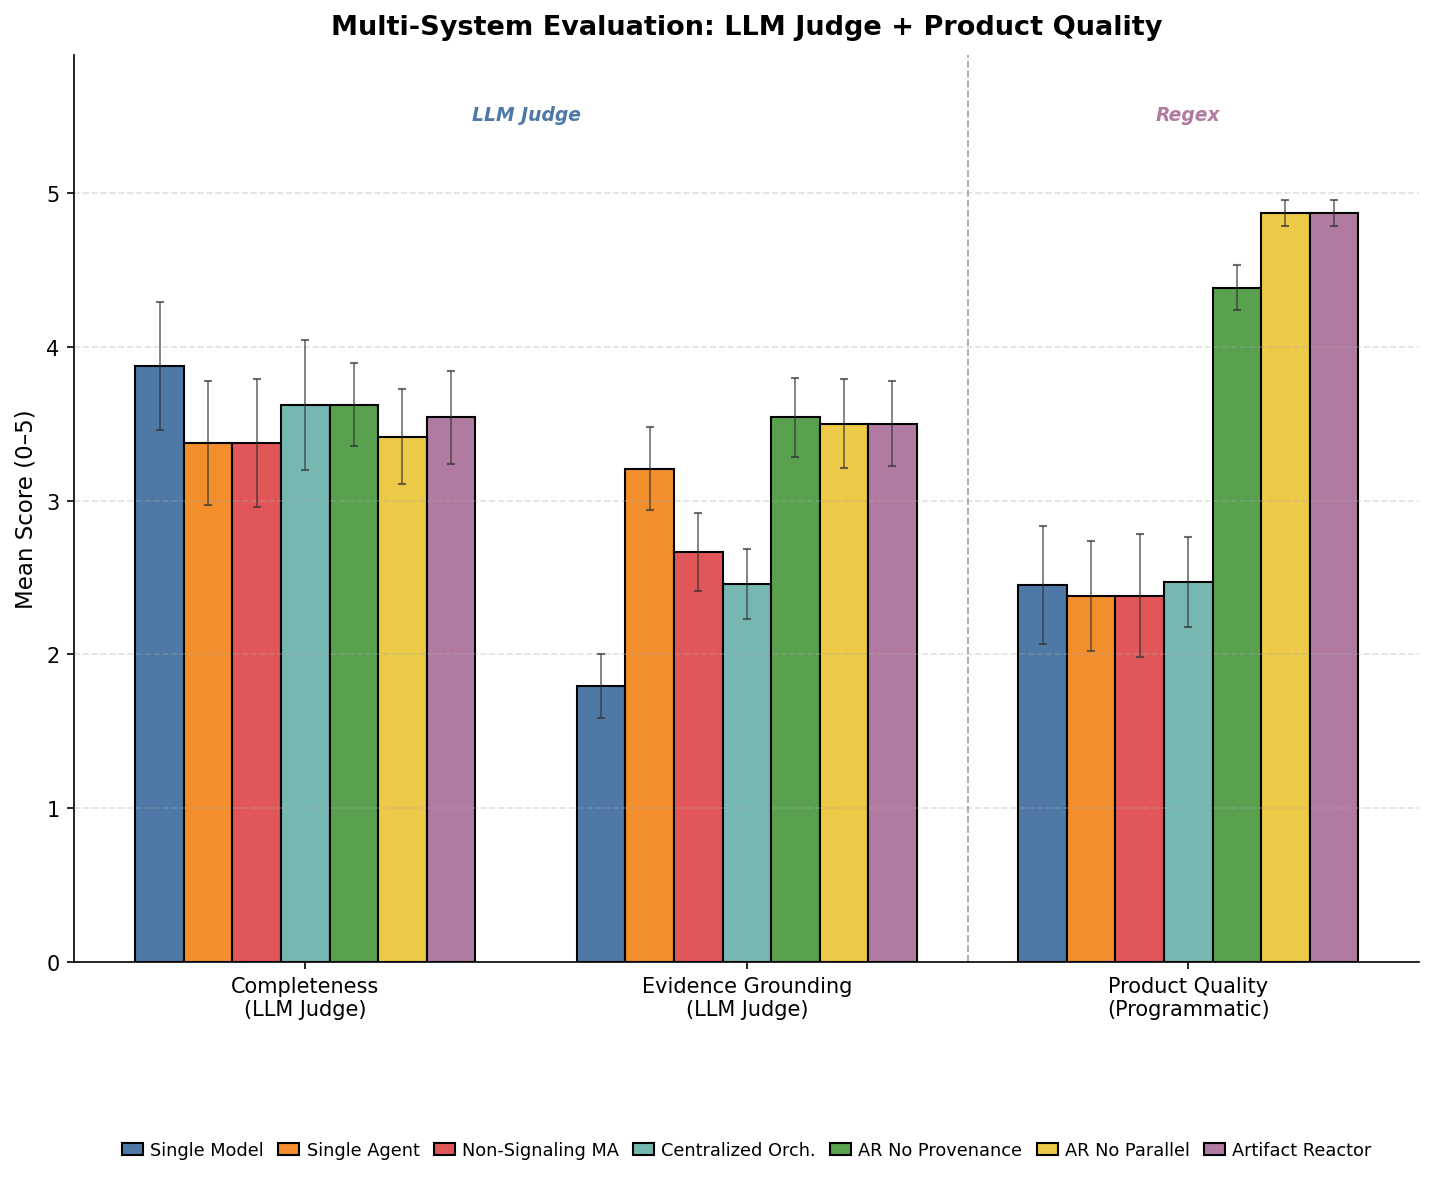


Per-system means:
                                completeness_score  evidence_grounding_score  product_quality_score
system                                                                                             
single_model_direct                          3.875                     1.792                  2.451
single_agent_with_tools                      3.375                     3.208                  2.382
non_signaling_multi_agent                    3.375                     2.667                  2.381
centralized_orchestration                    3.625                     2.458                  2.470
artifact_reactor_no_provenance               3.625                     3.542                  4.387
artifact_reactor_no_parallel                 3.417                     3.500                  4.872
artifact_reactor                             3.542                     3.500                  4.872


In [18]:
LLM_METRICS  = ["completeness_score", "evidence_grounding_score"]
PROG_METRIC  = "product_quality_score"
ALL_METRICS  = LLM_METRICS + [PROG_METRIC]

METRIC_LABELS = [
    "Completeness\n(LLM Judge)",
    "Evidence Grounding\n(LLM Judge)",
    "Product Quality\n(Programmatic)",
]

SYSTEM_LABELS = {
    "single_model_direct":            "Single Model",
    "single_agent_with_tools":        "Single Agent",
    "non_signaling_multi_agent":      "Non-Signaling MA",
    "centralized_orchestration":      "Centralized Orch.",
    "artifact_reactor_no_provenance": "AR No Provenance",
    "artifact_reactor_no_parallel":   "AR No Parallel",
    "artifact_reactor":               "Artifact Reactor",
}

# Colorblind-friendly palette (7 distinct colors)
PALETTE = [
    "#4E79A7",  # Single Model        — steel blue
    "#F28E2B",  # Single Agent        — orange
    "#E15759",  # Non-Signaling MA    — red
    "#76B7B2",  # Centralized Orch.   — teal
    "#59A14F",  # AR No Provenance    — green
    "#EDC948",  # AR No Parallel      — yellow
    "#B07AA1",  # Artifact Reactor    — purple
]

agg_mean = df_records.groupby("system")[ALL_METRICS].mean().reindex(SYSTEM_ORDER)
agg_sem  = df_records.groupby("system")[ALL_METRICS].sem().reindex(SYSTEM_ORDER)

n_metrics = len(ALL_METRICS)
n_systems = len(SYSTEM_ORDER)
bar_width  = 0.11
x          = np.arange(n_metrics)

fig, ax = plt.subplots(figsize=(10, 8), dpi=150)

bars_per_system = []
for i, system in enumerate(SYSTEM_ORDER):
    offsets = x + (i - n_systems / 2 + 0.5) * bar_width
    vals    = agg_mean.loc[system, ALL_METRICS].values
    errs    = agg_sem.loc[system, ALL_METRICS].values
    b = ax.bar(offsets, vals, width=bar_width, color=PALETTE[i],
               edgecolor="black", linewidth=1,
               yerr=errs, capsize=2,
               error_kw={"elinewidth": 0.8, "ecolor": "#333333", "alpha": 0.7})
    bars_per_system.append(b[0])

# divider between LLM judge and programmatic metric
ax.axvline(x=1.5, color="#888888", linestyle="--", linewidth=0.9, alpha=0.7)

# section labels
ax.text(0.5, 5.45, "LLM Judge",    ha="center", va="bottom", fontsize=9, color="#4E79A7", style="italic", fontweight="bold")
ax.text(2.0, 5.45, "Regex", ha="center", va="bottom", fontsize=9, color="#B07AA1", style="italic", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(METRIC_LABELS, fontsize=10)
ax.set_ylabel("Mean Score (0\u20135)", fontsize=11)
ax.set_ylim(0, 5.9)
ax.set_title("Multi-System Evaluation: LLM Judge + Product Quality", fontsize=13, fontweight="bold", pad=10)
ax.grid(axis="y", linestyle="--", alpha=0.35, color="#aaaaaa")
ax.spines[["top", "right"]].set_visible(False)

# Legend as a single horizontal row below the plot
ax.legend(
    bars_per_system,
    [SYSTEM_LABELS[s] for s in SYSTEM_ORDER],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=7,
    fontsize=8.5,
    frameon=False,
    handlelength=1.2,
    handletextpad=0.4,
    columnspacing=0.8,
)

plt.tight_layout()
plt.savefig("llm_judge_bar_plot.pdf", bbox_inches="tight")
plt.show()

print("\nPer-system means:")
print(agg_mean[ALL_METRICS].round(3).to_string())


## 8. Summary table

Same aggregates as the plot above, printed as mean ± std (rather than ± SEM) for a
quick text-only read of the per-system scores.

In [ ]:
grp   = df_records.groupby("system")
means = grp[ALL_METRICS].mean().reindex(SYSTEM_ORDER)
stds  = grp[ALL_METRICS].std().reindex(SYSTEM_ORDER)

header = f"{'System':<22} | {'Completeness':<18} | {'Evidence Grounding':<20} | {'Product Quality':<18}"
print(header)
print("-" * len(header))
for sys in SYSTEM_ORDER:
    label = SYSTEM_LABELS[sys]
    row = [f"{means.loc[sys, m]:.2f} ± {stds.loc[sys, m]:.2f}" for m in ALL_METRICS]
    print(f"{label:<22} | {row[0]:<18} | {row[1]:<20} | {row[2]:<18}")